# ICOS ObsPack zarr — station & gas explorer

Every station group is named `{TRIGRAM}{HEIGHT}` (e.g. `HTM150`) and can carry
`co2`, `ch4`, `n2o`, `co` (and more) as separate time-aligned variables. This
notebook builds a station index from the store's consolidated metadata, plots
one chosen series, draws the whole network's **coverage Gantt** (every
station × gas), and maps the stations.

*Advanced example — notebook 14 of the [sample series](README.md). Builds on
notebook 02. No account needed. (This started life as an ipywidgets viewer —
swap the parameter cell for dropdowns if you want it interactive again.)*

In [1]:
import re
from collections import defaultdict

import xarray as xr
import zarr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

STORE = "https://zarr.icos-cp.eu/icos-obspack.zarr"   # public proxy

GASES = ("co2", "ch4", "n2o", "co")
GAS_UNITS = {"co2": "ppm", "ch4": "ppb", "n2o": "ppb", "co": "ppb"}

_SID_RE = re.compile(r"^([A-Z]{3})(\d+)$")

# One consolidated-metadata fetch describes the whole store tree — group names,
# arrays and attrs — so the index below costs no data reads at all.
z = zarr.open_group(STORE, mode="r")   # URL works directly under zarr>=3

# {trigram: {height: station_id}} from the group names. Combined gas views
# ('co2', 'ch4', …) are lowercase and don't match the pattern.
_index: dict[str, dict[int, str]] = defaultdict(dict)
for sid in sorted(z.group_keys()):
    m = _SID_RE.match(sid)
    if m:
        _index[m.group(1)][int(m.group(2))] = sid

trigrams = sorted(_index)


def gases_in(sid: str) -> list[str]:
    """The gases present in a station group, in canonical order."""
    arrs = set(z[sid].array_keys())
    return [g for g in GASES if g in arrs]


print(f"{len(trigrams)} station sites, "
      f"{sum(len(v) for v in _index.values())} (site, height) groups")
print("example:", trigrams[0], "->", _index[trigrams[0]])

73 station sites, 165 (site, height) groups
example: ARN -> {10: 'ARN10', 50: 'ARN50', 95: 'ARN95'}


CO2 samples: 84,672  range: 2016-12-13 → 2026-08-10


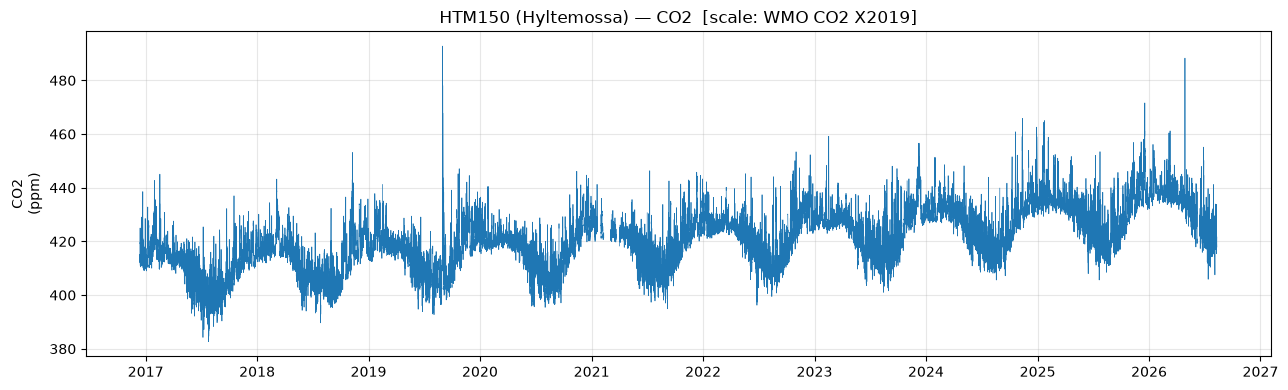

In [2]:
# Pick a station, intake height and gas — edit and re-run.
TRIGRAM, HEIGHT, GAS = "HTM", 150, "co2"

sid = _index[TRIGRAM][HEIGHT]
# Group-URL open: the group's own consolidated metadata, one small request.
ds = xr.open_zarr(f"{STORE}/{sid}", consolidated=True)

da    = ds[GAS]
time  = ds[f"time_{GAS}"].values
units = da.attrs.get("units", GAS_UNITS.get(GAS, ""))
cal   = ds.attrs.get(f"{GAS}_calibration_scale", "")
site  = ds.attrs.get("station_name") or ds.attrs.get("site_name", "")

title = f"{sid} ({site}) — {GAS.upper()}"
if cal:
    title += f"  [scale: {cal}]"
print(f"{GAS.upper()} samples: {len(time):,}  "
      f"range: {str(time[0])[:10]} → {str(time[-1])[:10]}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time, da.values, lw=0.5, color="tab:blue")
ax.set_ylabel(f"{GAS.upper()}\n({units})")
ax.set_title(title)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
fig.tight_layout()

## Data coverage overview (Gantt)

Each row = one `(station, gas)` pair.  Bars span the start → stop date
recorded in the group `.zattrs` for that gas.  Stations are grouped by
trigram, sorted by maximum height first within each trigram.

In [3]:
# ── Build coverage table from .zattrs ─────────────────────────────────────────

import pandas as pd

GAS_COLOR = {"co2": "#1f77b4", "ch4": "#2ca02c", "n2o": "#d62728", "co": "#ff7f0e"}

def _parse_iso(s: str):
    if not s:
        return None
    try:
        return pd.Timestamp(s)
    except Exception:
        return None

rows = []
for sid in sorted(z.group_keys()):
    m = _SID_RE.match(sid)
    if not m:
        continue
    trigram = m.group(1)
    height  = int(m.group(2))
    grp     = z[sid]
    attrs   = dict(grp.attrs)
    for gas in GASES:
        if gas not in grp:
            continue
        start = _parse_iso(attrs.get(f"{gas}_start_date"))
        stop  = _parse_iso(attrs.get(f"{gas}_stop_date"))
        if start is None or stop is None:
            continue
        rows.append({
            "station_id": sid,
            "trigram":    trigram,
            "height":     height,
            "gas":        gas,
            "start":      start,
            "stop":       stop,
            "duration":   (stop - start).days,
        })

cov = pd.DataFrame(rows)
print(f"{len(cov):,} (station, gas) coverage entries across {cov['station_id'].nunique()} stations")
cov.head()

506 (station, gas) coverage entries across 164 stations


,station_id,trigram,height,gas,start,stop,duration
0,ARN10,ARN,10,co2,2024-02-26 00:00:00+00:00,2026-08-10 23:00:00+00:00,896
1,ARN10,ARN,10,ch4,2024-02-26 00:00:00+00:00,2026-08-10 23:00:00+00:00,896
2,ARN10,ARN,10,co,2024-10-19 00:00:00+00:00,2026-08-10 23:00:00+00:00,660
3,ARN50,ARN,50,co2,2024-02-26 00:00:00+00:00,2026-08-10 23:00:00+00:00,896
4,ARN50,ARN,50,ch4,2024-02-26 00:00:00+00:00,2026-08-10 23:00:00+00:00,896


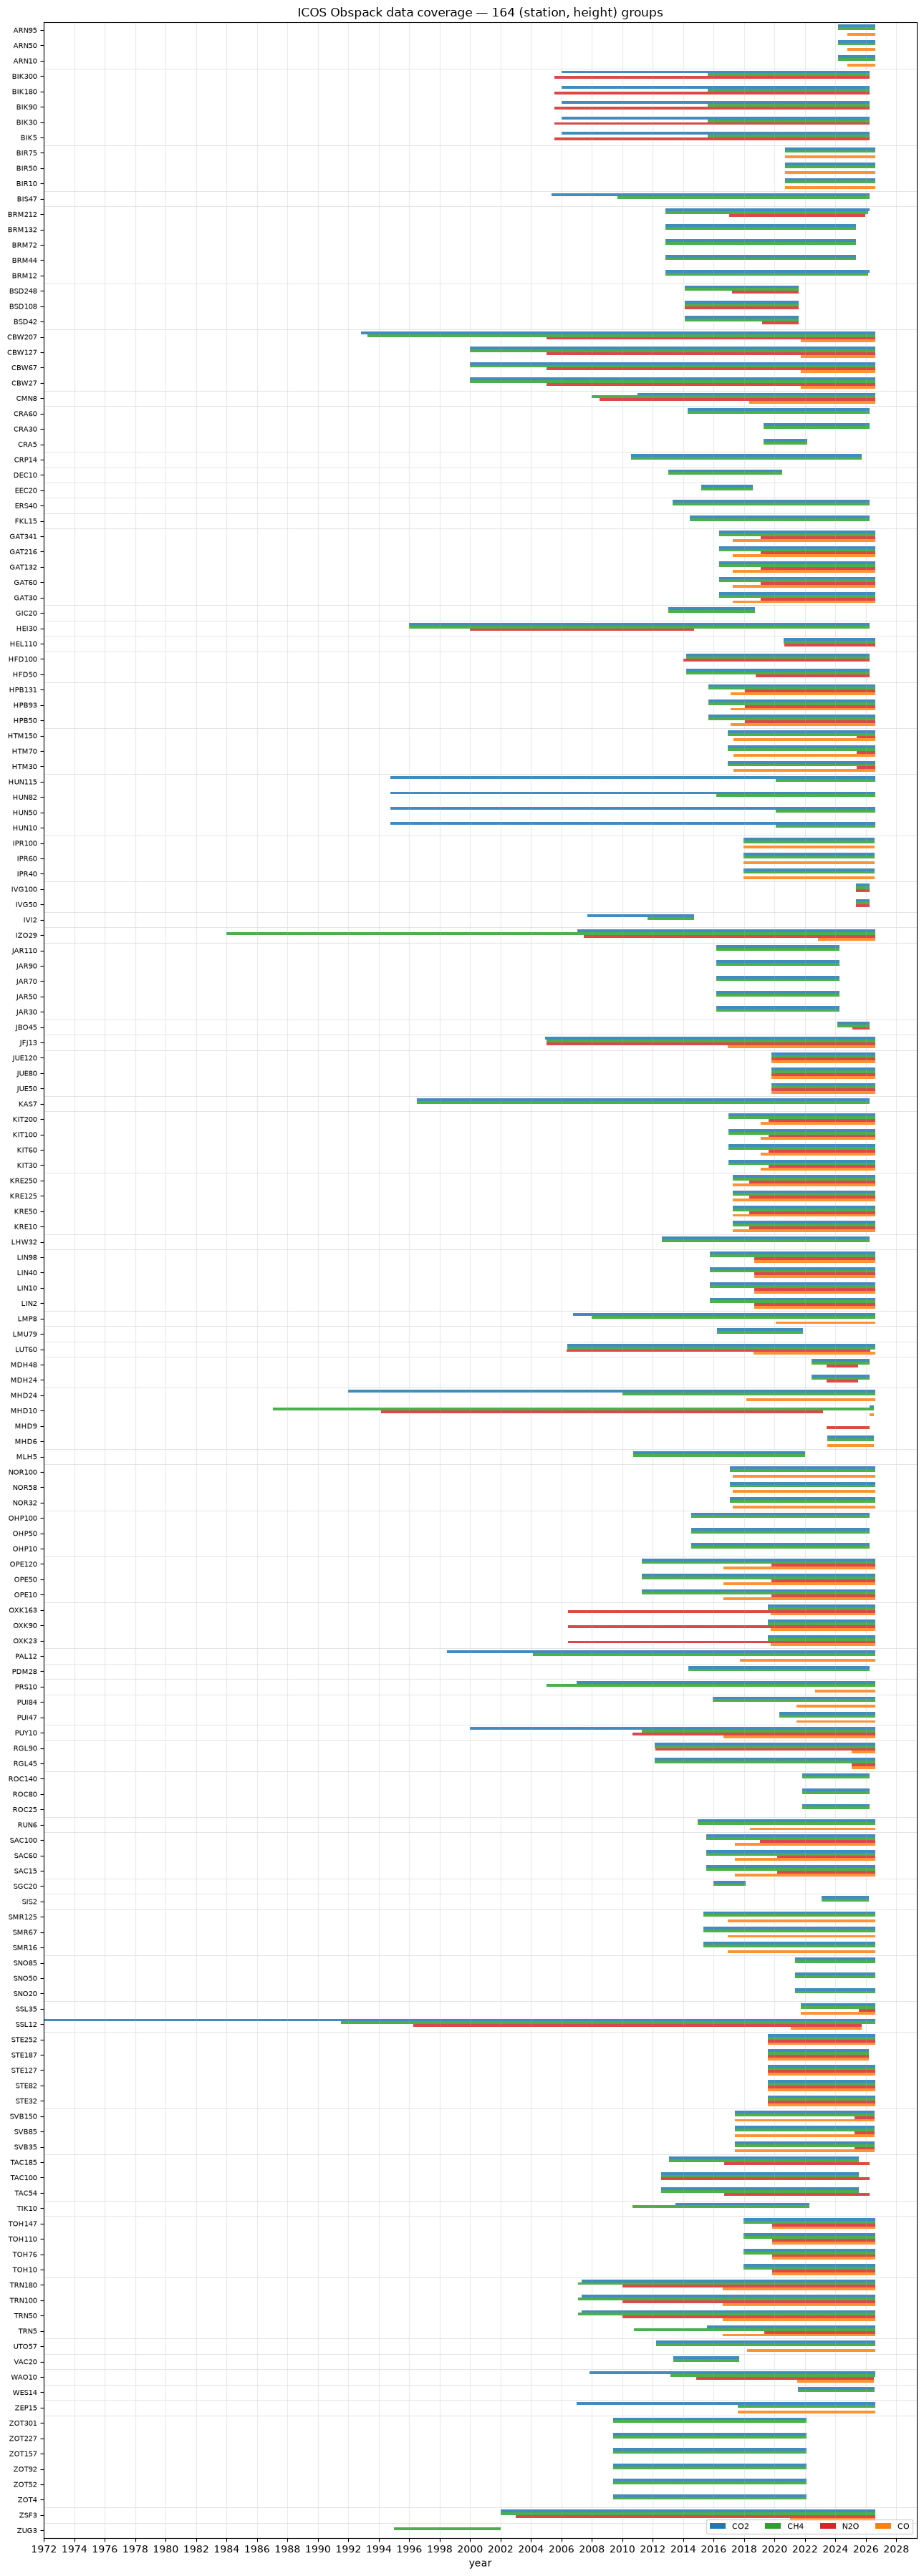

In [4]:
# ── Render the Gantt chart ────────────────────────────────────────────────────

# Order stations: by trigram, then height descending (tallest first within a tower)
station_order = (
    cov[["station_id", "trigram", "height"]]
       .drop_duplicates()
       .sort_values(["trigram", "height"], ascending=[True, False])
       ["station_id"]
       .tolist()
)
y_of = {sid: i for i, sid in enumerate(station_order)}

fig_h = max(6, len(station_order) * 0.22)
fig, ax = plt.subplots(figsize=(13, fig_h))

bar_h        = 0.18
gas_offset   = {"co2": -1.5, "ch4": -0.5, "n2o": 0.5, "co": 1.5}

for _, r in cov.iterrows():
    y = y_of[r["station_id"]] + gas_offset[r["gas"]] * bar_h
    ax.barh(y, (r["stop"] - r["start"]).days, left=r["start"],
            height=bar_h, color=GAS_COLOR[r["gas"]],
            edgecolor="none", alpha=0.85)

# Y axis: station IDs
ax.set_yticks(range(len(station_order)))
ax.set_yticklabels(station_order, fontsize=7)
ax.invert_yaxis()
ax.set_ylim(len(station_order) - 0.5, -0.5)

# Faint grid between trigrams
prev_trig = None
for i, sid in enumerate(station_order):
    trig = _SID_RE.match(sid).group(1)
    if prev_trig is not None and trig != prev_trig:
        ax.axhline(i - 0.5, color="0.85", lw=0.5)
    prev_trig = trig

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("year")
ax.grid(axis="x", alpha=0.25)
ax.set_title(f"ICOS Obspack data coverage — {len(station_order)} (station, height) groups")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GAS_COLOR[g], label=g.upper()) for g in GASES if g in GAS_COLOR],
          loc="lower right", fontsize=8, ncol=4, frameon=True)

fig.tight_layout()
plt.show()

## Station map

One marker per trigram (a tower with multiple heights collapses to one
location).  Click a marker to see the trigram, full station name, gases
measured, and sampling heights.

Plotting 73 stations on a Natural Earth projection


Text(0.5, 1.0, 'ICOS Obspack — 73 stations (Robinson / Natural Earth)')

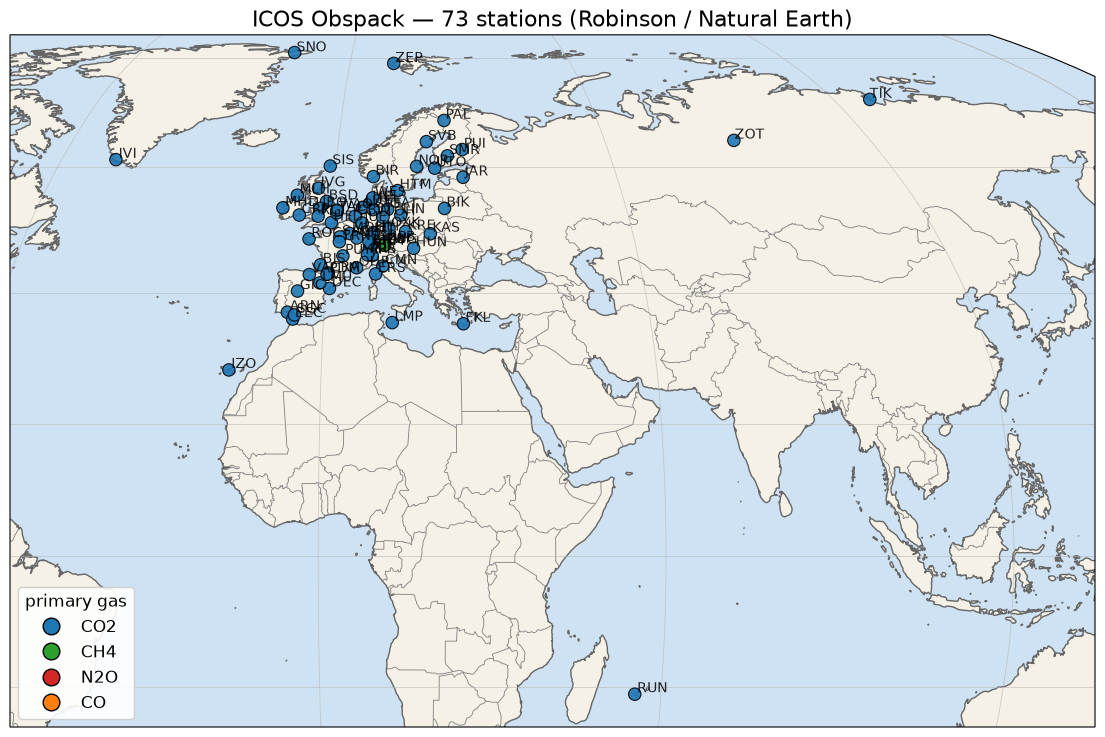

In [5]:
# Map code
# Cartopy map in Natural Earth (Robinson) projection (static).
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Aggregate per-trigram: pick lat/lon (all heights are colocated), collect heights/gases.
sites = []
for trig in trigrams:
    heights = sorted(_index[trig])
    sids    = [_index[trig][h] for h in heights]
    attrs0  = dict(z[sids[0]].attrs)
    lat = attrs0.get("latitude") or attrs0.get("site_latitude") or attrs0.get("station_lat")
    lon = attrs0.get("longitude") or attrs0.get("site_longitude") or attrs0.get("station_lon")
    if lat is None or lon is None:
        continue
    name    = attrs0.get("station_name", "") or attrs0.get("site_name", "") or attrs0.get("station_full_name", "")
    country = attrs0.get("country") or attrs0.get("country_code", attrs0.get("site_country", ""))
    pi      = attrs0.get("current_pi", "")

    gases_seen = set()
    height_rows = []
    for h, sid in zip(heights, sids):
        gs = gases_in(sid)
        gases_seen.update(gs)
        height_rows.append((h, gs))

    sites.append({
        "trigram": trig, "name": name, "country": country, "pi": pi,
        "lat": float(lat), "lon": float(lon),
        "gases": sorted(gases_seen, key=lambda g: ("co2","ch4","n2o","co").index(g)),
        "heights": height_rows,
    })

print(f"Plotting {len(sites)} stations on a Natural Earth projection")

# Bounding box of stations + margin (degrees)
lats = np.array([s["lat"] for s in sites])
lons = np.array([s["lon"] for s in sites])
margin = 5.0
extent = [lons.min() - margin, lons.max() + margin,
          lats.min() - margin, lats.max() + margin]

proj = ccrs.Robinson(central_longitude=15.0)

fig, ax = plt.subplots(figsize=(14, 19), subplot_kw={"projection": proj})

ax.add_feature(cfeature.LAND.with_scale("50m"),     facecolor="#f5f1e6")
ax.add_feature(cfeature.OCEAN.with_scale("50m"),    facecolor="#cfe2f3")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=1.0, edgecolor="0.4")
ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.6, edgecolor="0.5")
# draw_labels=False: labelled gridliners corrupt the inline backend's
# tight bbox (the saved figure collapses to a sliver).
ax.gridlines(draw_labels=False, linewidth=0.6, color="0.7", alpha=0.6)

ax.set_extent(extent, crs=ccrs.PlateCarree())

# One marker per station, colour by primary gas
gas_color = {"co2": "#1f77b4", "ch4": "#2ca02c", "n2o": "#d62728", "co": "#ff7f0e"}

xs     = [s["lon"] for s in sites]
ys     = [s["lat"] for s in sites]
colors = [gas_color.get((s["gases"] or ["co2"])[0], "gray") for s in sites]
scatter = ax.scatter(xs, ys, transform=ccrs.PlateCarree(),
                     s=80, c=colors, edgecolors="black",
                     linewidths=0.8, alpha=0.9, zorder=5)

# Always-visible trigram labels next to each marker
for s in sites:
    ax.text(s["lon"] + 0.4, s["lat"] + 0.3, s["trigram"],
            transform=ccrs.PlateCarree(),
            fontsize=10, color="black", alpha=0.85, zorder=6)

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], marker="o", linestyle="",
                          markerfacecolor=gas_color[g], markeredgecolor="black",
                          markersize=12, label=g.upper())
                   for g in ("co2","ch4","n2o","co")],
          loc="lower left", fontsize=12, framealpha=0.9, title="primary gas",
          title_fontsize=12)

ax.set_title(f"ICOS Obspack — {len(sites)} stations (Robinson / Natural Earth)",
             fontsize=16)